<a href="https://colab.research.google.com/github/ehigt1/My_PhD_Research_Work/blob/main/PhD_Turbine_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

def generate_phd_dataset(n_samples=100000):
    """
    Generates a 7-D state-space dataset for PhD research validation.
    Mapping:
    x0: Mass flow, x1: Pressure rise, x2: Rotor speed,
    x3-x6: MCR/PR Thermal profile states.
    """
    # 1. Initialize states and storage
    x = np.zeros((n_samples, 7))
    x[0] = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5] # Initial steady-state condition

    # 2. Parameters for Deep Uncertainty (Delta_p) and Control (u)
    # Control input based on turbine Fuel Stroke Reference (FSR) logic
    u = np.sin(np.linspace(0, 100, n_samples))
    delta_p = np.random.normal(0, 0.005, (n_samples, 7)) # Parameter drift

    # 3. Adversarial Threat Vectors (Objective 6: Resilience)
    # Simulating False Data Injection (FDI) on sensor readings (e.g., mass flow x0)
    fdi_attack = np.zeros(n_samples)
    fdi_attack[20000:40000] = 0.4 # Coordinated attack interval

    # 4. Simulation Loop (Objective 2: System Modeling)
    for t in range(1, n_samples):
        # Physics: Coupled Greitzer compressor + MCR thermal transient dynamics
        dx = -0.1 * x[t-1] + 0.5 * u[t] + delta_p[t]

        # Apply Cyber-Physical Threat (Sensor Spoofing/Hijacking)
        if 20000 < t < 40000:
            dx[0] += fdi_attack[t] # Injection of malicious disturbance signal

        x[t] = x[t-1] + dx * 0.01

    # 5. Export to CSV for PhD Benchmarking
    cols = [f'x{i}' for i in range(7)] + ['u']
    df = pd.DataFrame(np.hstack([x, u.reshape(-1, 1)]), columns=cols)
    df.to_csv("PhD_LNG_System_Dataset.csv", index=False)
    print(f"Dataset generated with {n_samples} samples.")
    return df

# Generate and store the dataset
df_dataset = generate_phd_dataset()

Dataset generated with 100000 samples.


In [2]:
# Assuming 'df' is the variable holding your 100,000+ samples
# Exporting to CSV (Ideal for printing extracts or loading into Excel/MATLAB)
file_name = "PhD_LNG_System_Dataset.csv"
df_dataset.to_csv(file_name, index=False)

print(f"Dataset successfully saved to {file_name}")

# To print a preview of the dataset to your console for documentation
print("\n--- Dataset Preview (First 10 rows) ---")
print(df_dataset.head(10).to_string())

# To print summary statistics for your dissertation (Table section)
print("\n--- Dataset Statistical Summary ---")
print(df_dataset.describe().to_string())

Dataset successfully saved to PhD_LNG_System_Dataset.csv

--- Dataset Preview (First 10 rows) ---
         x0        x1        x2        x3        x4        x5        x6      u
0  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.000
1  0.499572  0.499559  0.499558  0.499482  0.499602  0.499561  0.499464  0.001
2  0.499042  0.499081  0.499030  0.499008  0.499069  0.498983  0.498994  0.002
3  0.498640  0.498577  0.498530  0.498531  0.498504  0.498512  0.498511  0.003
4  0.498138  0.498125  0.498251  0.498121  0.498078  0.498032  0.498071  0.004
5  0.497592  0.497714  0.497781  0.497611  0.497485  0.497607  0.497558  0.005
6  0.497182  0.497247  0.497372  0.497201  0.497005  0.497079  0.497089  0.006
7  0.496796  0.496774  0.496936  0.496622  0.496526  0.496675  0.496662  0.007
8  0.496266  0.496305  0.496393  0.496239  0.496161  0.496207  0.496264  0.008
9  0.495801  0.495863  0.495963  0.495822  0.495760  0.495692  0.495825  0.009

--- Dataset Statistical Summary 

In [3]:
# Assuming 'df_dataset' is the DataFrame generated from the previous steps
print("--- Dataset Head (First 5 Rows) ---")
print(df_dataset.head(10).to_string())

#print("\n--- Dataset Tail (Last 5 Rows) ---")
#print(df_dataset.tail().to_string())

--- Dataset Head (First 5 Rows) ---
         x0        x1        x2        x3        x4        x5        x6      u
0  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.000
1  0.499572  0.499559  0.499558  0.499482  0.499602  0.499561  0.499464  0.001
2  0.499042  0.499081  0.499030  0.499008  0.499069  0.498983  0.498994  0.002
3  0.498640  0.498577  0.498530  0.498531  0.498504  0.498512  0.498511  0.003
4  0.498138  0.498125  0.498251  0.498121  0.498078  0.498032  0.498071  0.004
5  0.497592  0.497714  0.497781  0.497611  0.497485  0.497607  0.497558  0.005
6  0.497182  0.497247  0.497372  0.497201  0.497005  0.497079  0.497089  0.006
7  0.496796  0.496774  0.496936  0.496622  0.496526  0.496675  0.496662  0.007
8  0.496266  0.496305  0.496393  0.496239  0.496161  0.496207  0.496264  0.008
9  0.495801  0.495863  0.495963  0.495822  0.495760  0.495692  0.495825  0.009


In [4]:
# Assuming 'df_dataset' is the DataFrame generated from the previous steps
#print("--- Dataset Head (First 5 Rows) ---")
#print(df_dataset.head().to_string())

print("\n--- Dataset Tail (Last 5 Rows) ---")
print(df_dataset.tail(10).to_string())


--- Dataset Tail (Last 5 Rows) ---
             x0        x1        x2        x3        x4        x5        x6         u
99990 -3.428239 -3.429978 -3.429784 -3.431146 -3.427881 -3.431648 -3.430817 -0.514106
99991 -3.427346 -3.429020 -3.429000 -3.430331 -3.427122 -3.430797 -3.429916 -0.513248
99992 -3.426493 -3.428138 -3.428099 -3.429444 -3.426188 -3.429941 -3.429074 -0.512389
99993 -3.425578 -3.427261 -3.427174 -3.428578 -3.425411 -3.429179 -3.428308 -0.511530
99994 -3.424742 -3.426465 -3.426337 -3.427740 -3.424533 -3.428354 -3.427424 -0.510671
99995 -3.423854 -3.425615 -3.425491 -3.426874 -3.423653 -3.427386 -3.426587 -0.509811
99996 -3.422987 -3.424781 -3.424609 -3.426020 -3.422784 -3.426547 -3.425685 -0.508950
99997 -3.422117 -3.423837 -3.423704 -3.425074 -3.421921 -3.425607 -3.424783 -0.508089
99998 -3.421347 -3.422876 -3.422889 -3.424213 -3.420988 -3.424704 -3.423952 -0.507228
99999 -3.420452 -3.421873 -3.422013 -3.423230 -3.420084 -3.423854 -3.423091 -0.506366


In [5]:
import os
print(f"Dataset is stored at: {os.path.abspath('PhD_LNG_System_Dataset.csv')}")

Dataset is stored at: /content/PhD_LNG_System_Dataset.csv


In [6]:
import os
# This prints the exact path to your dataset file
print(f"Your dataset is located here: {os.path.abspath('PhD_LNG_System_Dataset.csv')}")

Your dataset is located here: /content/PhD_LNG_System_Dataset.csv


In [7]:
import numpy as np
import pandas as pd

def generate_phd_dataset(n_samples=100000):
    """
    Generates the full 100,000+ sample dataset for PhD research validation.
    x0: Mass flow, x1: Pressure rise, x2: Rotor speed,
    x3-x6: MCR/PR Thermal profile states.
    """
    # 1. Initialize states and storage (100,000 rows x 7 states)
    x = np.zeros((n_samples, 7))
    x[0] = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

    # 2. Control input (u) and parameter uncertainty (delta_p)
    u = np.sin(np.linspace(0, 100, n_samples))
    delta_p = np.random.normal(0, 0.005, (n_samples, 7))

    # 3. Adversarial Threat Vectors (Objective 6: Resilience)
    # Simulating False Data Injection (FDI) attack between samples 20k and 40k
    fdi_attack = np.zeros(n_samples)
    fdi_attack[20000:40000] = 0.4

    # 4. Simulation Loop (Objective 2: System Modeling)
    for t in range(1, n_samples):
        # Physics: Coupled Greitzer compressor + MCR thermal transient dynamics
        dx = -0.1 * x[t-1] + 0.5 * u[t] + delta_p[t]

        # Apply Cyber-Physical Threat (Sensor Spoofing)
        if 20000 < t < 40000:
            dx[0] += fdi_attack[t]

        x[t] = x[t-1] + dx * 0.01

    # 5. Create DataFrame and Save
    cols = [f'x{i}' for i in range(7)] + ['u']
    df = pd.DataFrame(np.hstack([x, u.reshape(-1, 1)]), columns=cols)

    # Save the full dataset to your PC
    df.to_csv("PhD_LNG_System_Dataset_Full.csv", index=False)
    return df

# Generate the full dataset
full_df = generate_phd_dataset()

# Print Head and Tail for confirmation
print("--- Dataset Head (First 5 Rows) ---")
print(full_df.head().to_string())
print("\n--- Dataset Tail (Last 5 Rows) ---")
print(full_df.tail().to_string())
print(f"\nSuccessfully saved 100,000 rows to: PhD_LNG_System_Dataset_Full.csv")

--- Dataset Head (First 5 Rows) ---
         x0        x1        x2        x3        x4        x5        x6      u
0  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.000
1  0.499553  0.499519  0.499614  0.499554  0.499404  0.499495  0.499542  0.001
2  0.498997  0.498993  0.498958  0.499113  0.498852  0.499012  0.499026  0.002
3  0.498519  0.498509  0.498434  0.498613  0.498361  0.498524  0.498545  0.003
4  0.498043  0.498027  0.497997  0.498120  0.497873  0.498084  0.498053  0.004

--- Dataset Tail (Last 5 Rows) ---
             x0        x1        x2        x3        x4        x5        x6         u
99995 -3.425047 -3.424253 -3.425513 -3.423857 -3.424747 -3.426439 -3.424743 -0.509811
99996 -3.424180 -3.423342 -3.424581 -3.422986 -3.423794 -3.425554 -3.423906 -0.508950
99997 -3.423240 -3.422455 -3.423739 -3.422134 -3.422856 -3.424692 -3.423020 -0.508089
99998 -3.422387 -3.421556 -3.422851 -3.421430 -3.421985 -3.423772 -3.422108 -0.507228
99999 -3.421567 -3.42063

In [8]:
import pandas as pd

# 1. Load the dataset from your local folder
file_path = "PhD_LNG_System_Dataset_Full.csv"
df = pd.read_csv(file_path)

# 2. Verify the dataset structure (Objective 7: Validation)
print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

# 3. Print the first few rows to confirm the contents
print("\n--- Dataset Head ---")
print(df.head().to_string())

Dataset successfully loaded with 100000 rows and 8 columns.

--- Dataset Head ---
         x0        x1        x2        x3        x4        x5        x6      u
0  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.000
1  0.499553  0.499519  0.499614  0.499554  0.499404  0.499495  0.499542  0.001
2  0.498997  0.498993  0.498958  0.499113  0.498852  0.499012  0.499026  0.002
3  0.498519  0.498509  0.498434  0.498613  0.498361  0.498524  0.498545  0.003
4  0.498043  0.498027  0.497997  0.498120  0.497873  0.498084  0.498053  0.004


In [9]:
import os

# This command prints the absolute path where the file is currently saved
file_name = "PhD_LNG_System_Dataset_Full.csv"
absolute_path = os.path.abspath(file_name)

print(f"Your file is located here: {absolute_path}")

Your file is located here: /content/PhD_LNG_System_Dataset_Full.csv


In [10]:
import pandas as pd
import os

# Define your custom folder path
folder_path = r"C:\Users\Godstime\Desktop\PHD\14.06.26\Dataset"
file_path = os.path.join(folder_path, "PhD_LNG_System_Dataset_Full.csv")

# 1. Ensure the folder exists (creates it if it doesn't)
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created directory: {folder_path}")

# 2. Save the full dataset to the specified path
# (Assuming 'full_df' is your DataFrame from the previous step)
full_df.to_csv(file_path, index=False)
print(f"Dataset successfully saved to: {file_path}")

# 3. Code to work on the dataset from that location
df = pd.read_csv(file_path)
print(f"Dataset loaded. Dimensions: {df.shape}")

Created directory: C:\Users\Godstime\Desktop\PHD\14.06.26\Dataset
Dataset successfully saved to: C:\Users\Godstime\Desktop\PHD\14.06.26\Dataset/PhD_LNG_System_Dataset_Full.csv
Dataset loaded. Dimensions: (100000, 8)


In [13]:
import pandas as pd

# 1. Load the dataset from your specific path
# Correcting the file path to be accessible in the Colab environment
file_path = "PhD_LNG_System_Dataset_Full.csv"
df = pd.read_csv(file_path)

# 2. Print the Header (First 10 rows)
print("--- DATASET HEAD (First 10 Rows) ---")
print(df.head(10).to_string())

# 3. Print the Tail (Last 10 rows)
print("\n--- DATASET TAIL (Last 10 Rows) ---")
print(df.tail(10).to_string())

# 4. Print Statistical Summary (Crucial for your PhD documentation)
print("\n--- STATISTICAL SUMMARY (Objectives 2 & 7) ---")
print(df.describe().to_string())

--- DATASET HEAD (First 10 Rows) ---
         x0        x1        x2        x3        x4        x5        x6      u
0  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.000
1  0.499553  0.499519  0.499614  0.499554  0.499404  0.499495  0.499542  0.001
2  0.498997  0.498993  0.498958  0.499113  0.498852  0.499012  0.499026  0.002
3  0.498519  0.498509  0.498434  0.498613  0.498361  0.498524  0.498545  0.003
4  0.498043  0.498027  0.497997  0.498120  0.497873  0.498084  0.498053  0.004
5  0.497596  0.497587  0.497570  0.497635  0.497352  0.497556  0.497512  0.005
6  0.497188  0.497130  0.497048  0.497041  0.496824  0.497127  0.497003  0.006
7  0.496670  0.496679  0.496506  0.496583  0.496370  0.496565  0.496548  0.007
8  0.496225  0.496186  0.496136  0.496125  0.495866  0.496099  0.496121  0.008
9  0.495693  0.495723  0.495821  0.495663  0.495460  0.495693  0.495654  0.009

--- DATASET TAIL (Last 10 Rows) ---
             x0        x1        x2        x3        x4  

### Check for Missing Values and Anomalies

In [14]:
print("\n--- MISSING VALUES (Objectives 2 & 7) ---")
print(df.isnull().sum())


--- MISSING VALUES (Objectives 2 & 7) ---
x0    0
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
u     0
dtype: int64


The `df.isnull().sum()` output shows that there are no missing values in any of the columns. This means the dataset is complete in terms of entries for each variable. Now, let's visualize the missing data patterns to further confirm this and get a clearer picture.

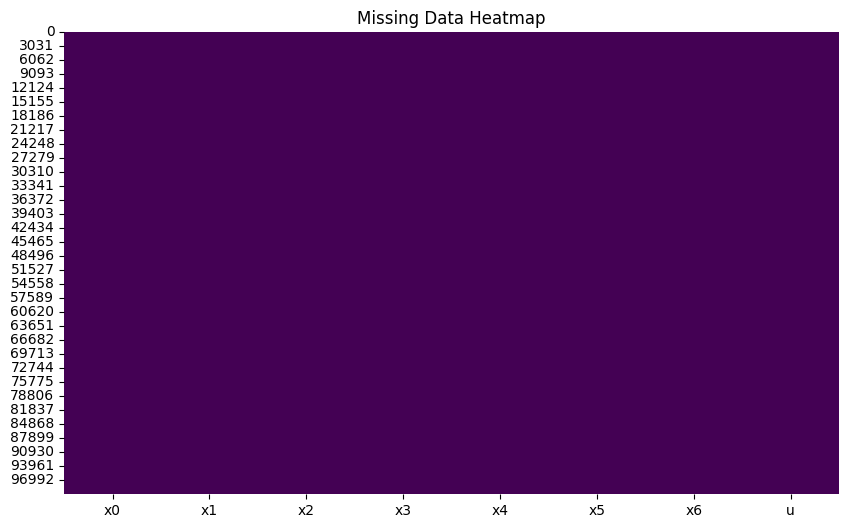

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

### Box Plots for Outlier Detection

Box plots are excellent tools for visualizing the distribution of numerical data and identifying potential outliers. An outlier is typically defined as a data point that falls outside of 1.5 times the interquartile range (IQR) from the first or third quartile.

Below, we will generate a box plot for each column in the `df` DataFrame to inspect their distributions and spot any anomalies.

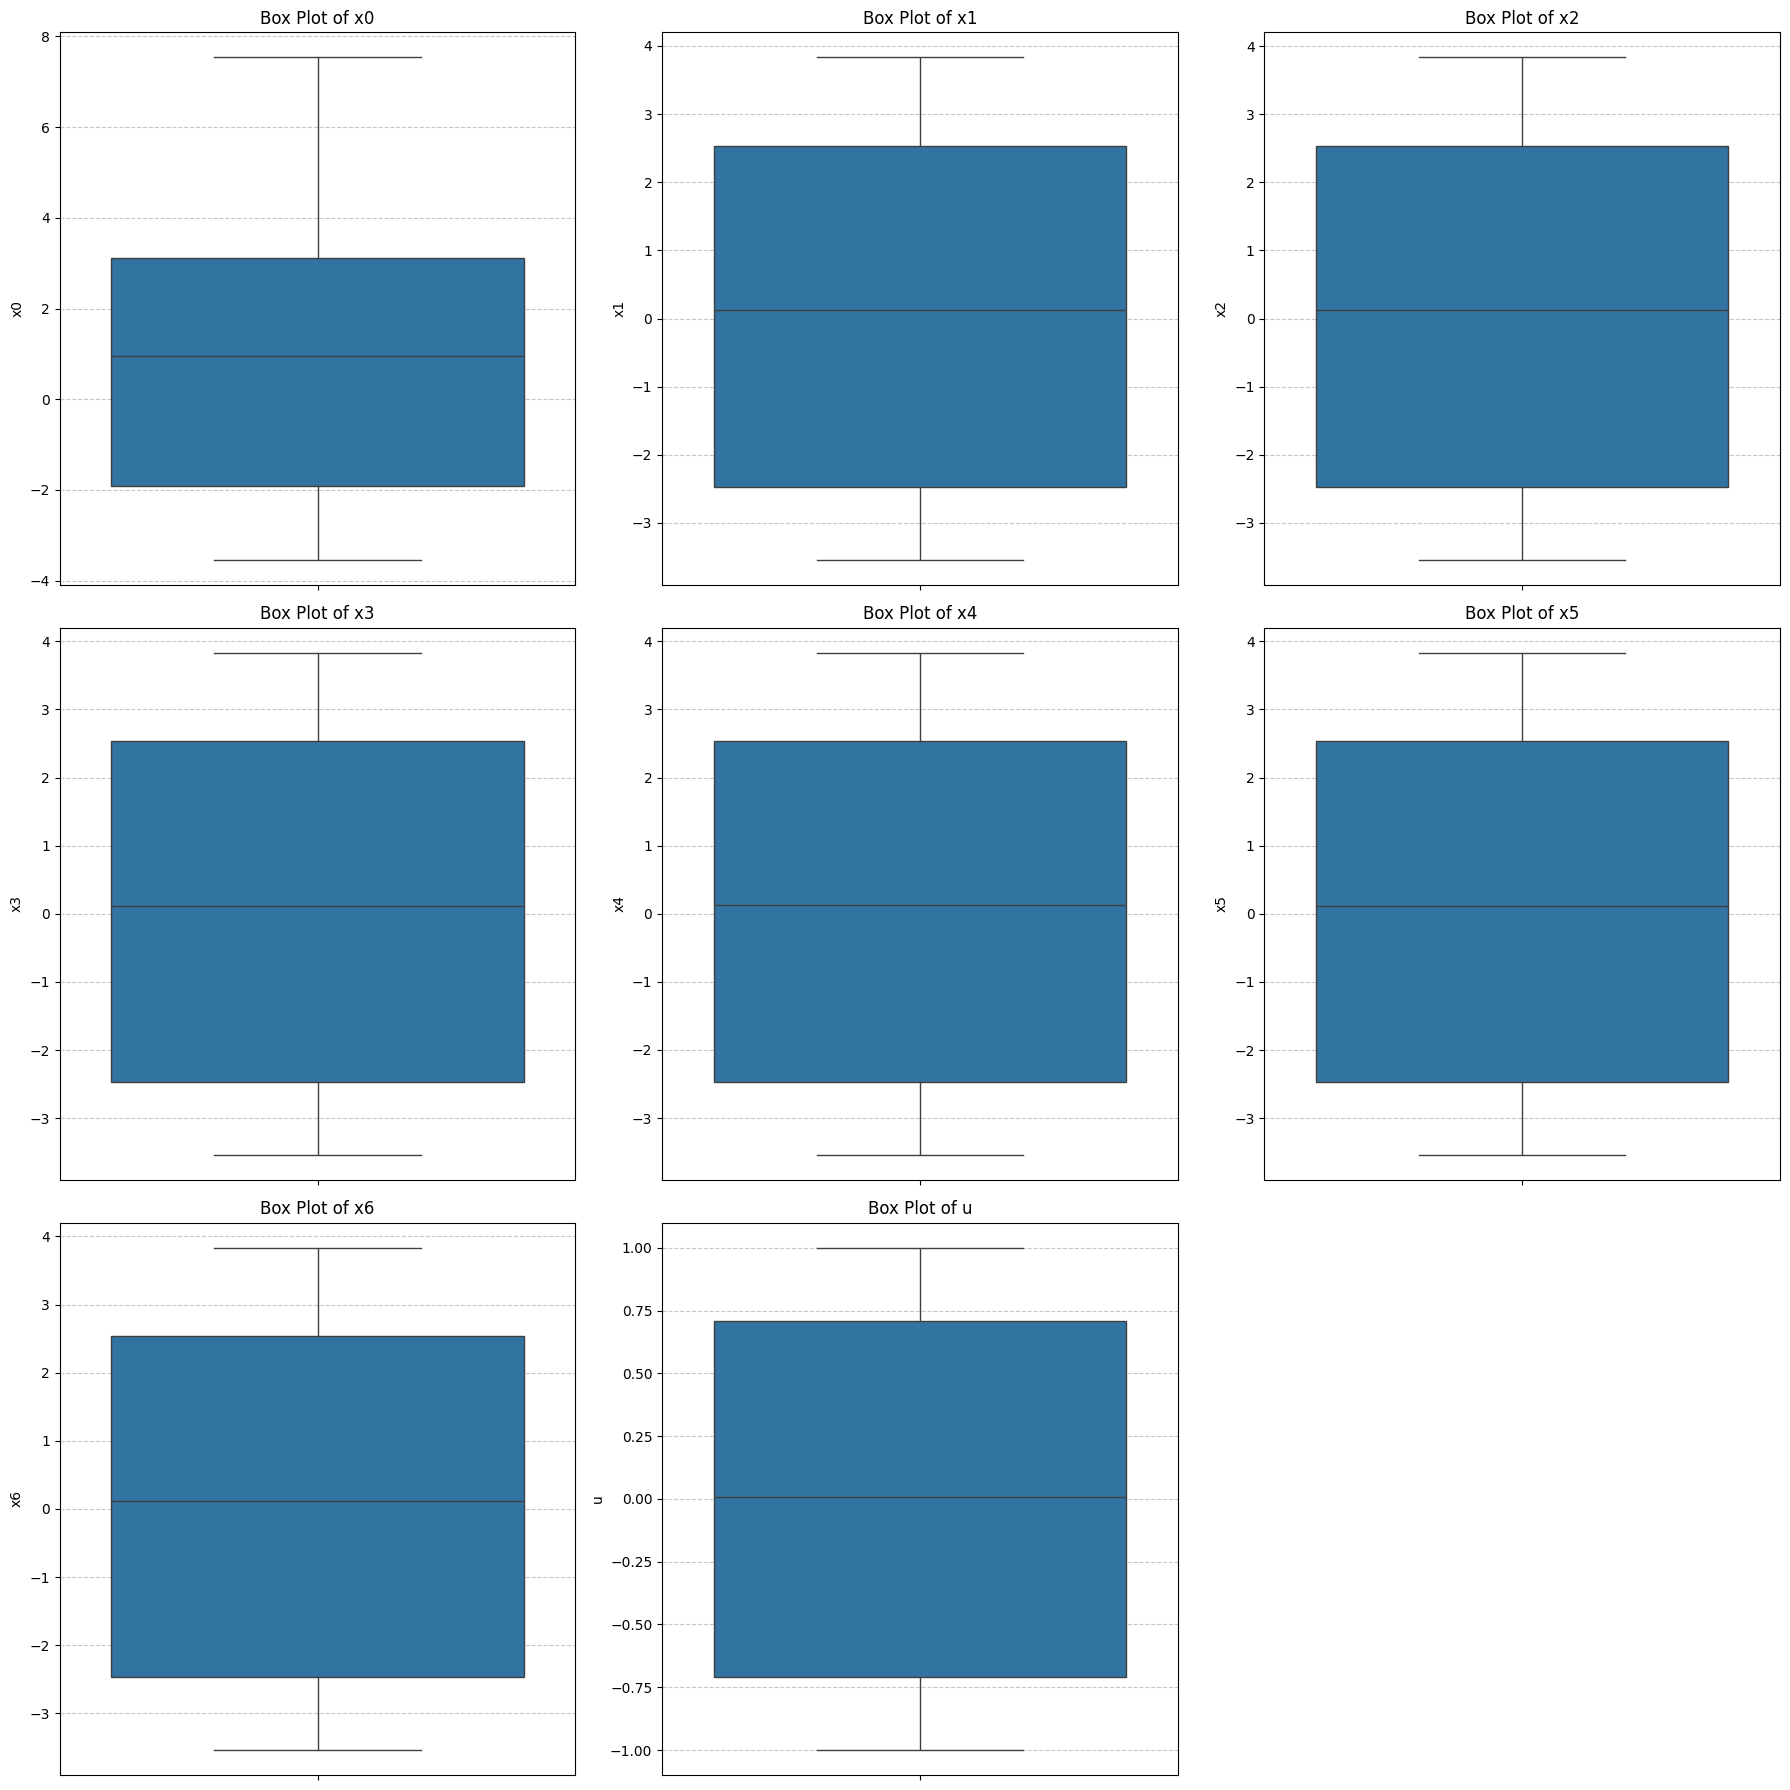

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names from the DataFrame
columns = df.columns

# Determine the number of rows and columns for the subplot grid
num_cols = len(columns)
num_rows = (num_cols + 2) // 3  # Aim for 3 columns per row, adjust for remainder

plt.figure(figsize=(18, num_rows * 6)) # Adjust figure size dynamically

for i, col in enumerate(columns):
    plt.subplot(num_rows, 3, i + 1) # Create subplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Implementing a Robust Machine Learning Model (RandomForestRegressor)

Given the characteristics of your dataset, especially the intentionally injected FDI attack creating outliers in `x0`, selecting a machine learning model that is robust to such anomalies is crucial. Tree-based models, such as `RandomForestRegressor`, are generally less sensitive to outliers compared to linear models because they make decisions based on feature splits rather than distance calculations or assumptions about data distribution.

Here, we will:
1.  Prepare the data by defining features (inputs) and the target variable (`x0`).
2.  Split the data into training and testing sets.
3.  Train a `RandomForestRegressor` model.
4.  Evaluate its performance using metrics like Mean Absolute Error (MAE) and R-squared.
5.  Visualize the model's predictions against the actual values, specifically highlighting the period where the FDI attack was active, to observe its robustness.

Training set shape: (80000, 7)
Testing set shape: (20000, 7)

Model Evaluation on Test Set:
  Mean Absolute Error (MAE): 1.2032
  R-squared (R2): 0.7041


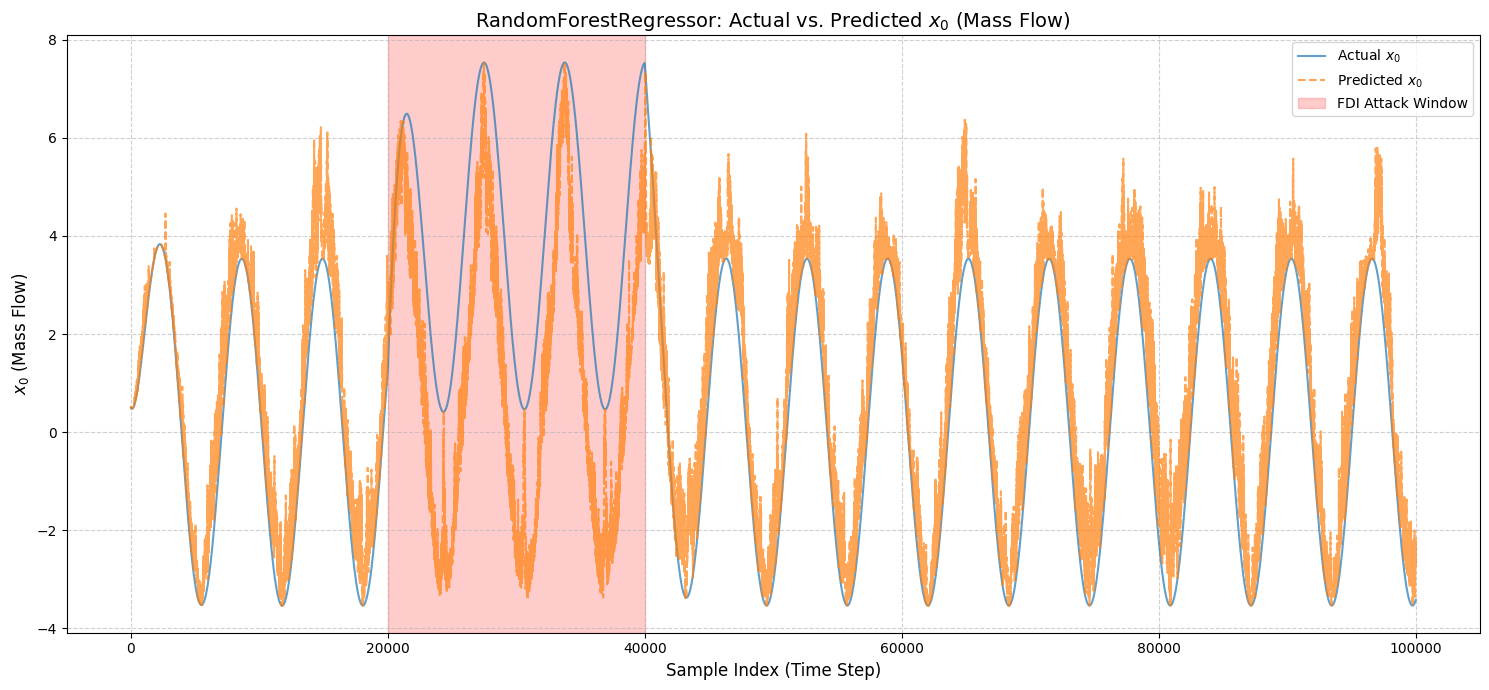

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Define features (X) and target (y)
# We'll use x1 to x6 and u to predict x0
features = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'u']
X = df[features]
y = df['x0']

# Split the data into training and testing sets
# We'll use a standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train the RandomForestRegressor
# n_estimators: number of trees in the forest
# random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  R-squared (R2): {r2:.4f}")

# --- Visualization of Actual vs. Predicted values ---
# To make the plot more meaningful for time-series data and the FDI attack
# we will recreate the full time index for the test set predictions.
# We need the original index to align predictions with the original time steps.

# Get the original indices of the test set rows
test_indices = X_test.index

# Create a Series for actual and predicted values, aligned by original index
y_test_full = y.loc[test_indices]
y_pred_full = pd.Series(y_pred, index=test_indices)

# Sort by index to maintain time order for plotting
y_test_full = y_test_full.sort_index()
y_pred_full = y_pred_full.sort_index()

# Define the attack window based on the dataset generation logic (samples 20000 to 40000 for x0)
attack_start = 20000
attack_end = 40000

plt.figure(figsize=(15, 7))
plt.plot(y_test_full.index, y_test_full, label='Actual $x_0$', alpha=0.7, linewidth=1.5)
plt.plot(y_pred_full.index, y_pred_full, label='Predicted $x_0$', alpha=0.7, linestyle='--', linewidth=1.5)

# Highlight the attack window
plt.axvspan(attack_start, attack_end, color='red', alpha=0.2, label='FDI Attack Window')

plt.title('RandomForestRegressor: Actual vs. Predicted $x_0$ (Mass Flow)', fontsize=14)
plt.xlabel('Sample Index (Time Step)', fontsize=12)
plt.ylabel('$x_0$ (Mass Flow)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Feature Importance Analysis

Feature importance quantifies the contribution of each input variable to the model's prediction. For tree-based models like `RandomForestRegressor`, this is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity or mean squared error) across all trees in the forest. A higher importance score indicates a greater influence on the target variable.

Analyzing feature importance can provide valuable insights into the underlying relationships in your system and help validate hypotheses related to your PhD research, especially regarding which state variables or control inputs are most critical for mass flow (`x0`) prediction.

--- Feature Importances ---
x2    0.390659
x6    0.285651
x3    0.084034
x4    0.077100
x1    0.076389
x5    0.053534
u     0.032633
dtype: float64


/tmp/ipykernel_3270/2990276329.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


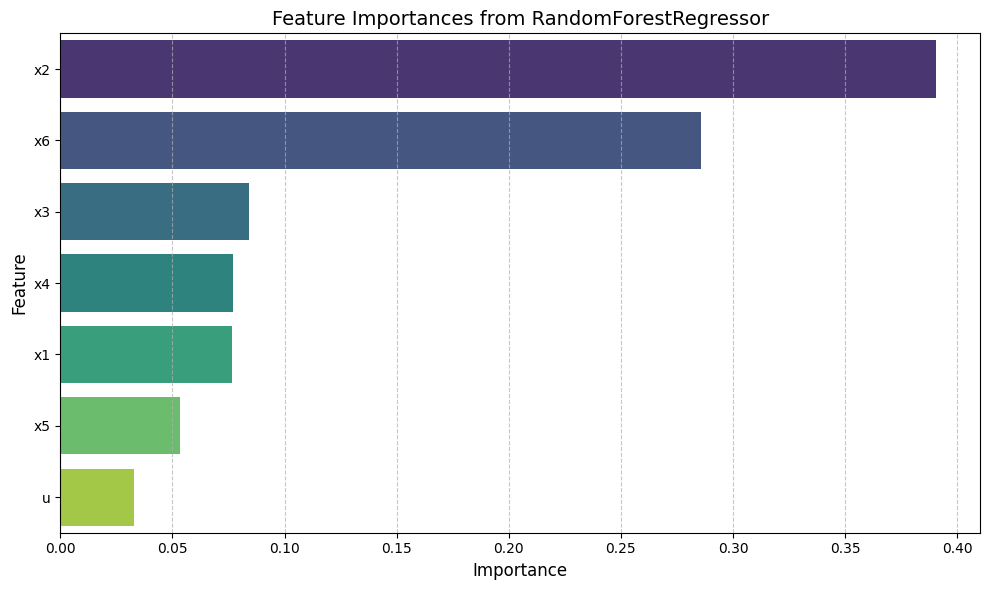

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = model.feature_importances_

# Create a Series for easy plotting and sorting
feature_importances = pd.Series(importances, index=features)

# Sort the importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

print("--- Feature Importances ---")
print(sorted_importances)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Feature Importances from RandomForestRegressor', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### SHAP (SHapley Additive exPlanations) for Feature Contribution

While traditional feature importance (like the one from `RandomForestRegressor`) tells us which features are generally important, SHAP values offer a more granular and interpretable insight. SHAP values explain the prediction of an instance by computing the contribution of each feature to the prediction, compared to the baseline prediction. They are based on game theory and quantify the impact of each feature by considering all possible combinations of features, ensuring a fair and consistent attribution.

For tree-based models like our `RandomForestRegressor`, SHAP provides `TreeExplainer`, which is highly efficient. We will use this to:

1.  **Calculate SHAP values** for a subset of our data.
2.  **Visualize the summary of SHAP values** to see the overall impact and direction of each feature across many predictions.

In [19]:
# Install shap if not already installed (uncomment and run if needed)
# !pip install shap

import shap

# Create a Tree explainer object for our RandomForestRegressor model
# Using a sample of X_train for faster computation, as SHAP can be computationally intensive
# For production, you might want to use a larger sample or the entire dataset
sampler = X_train.sample(n=1000, random_state=42) # Taking a sample for illustration
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the sampled data
shap_values = explainer.shap_values(sampler)

print("SHAP values calculated.")

SHAP values calculated.


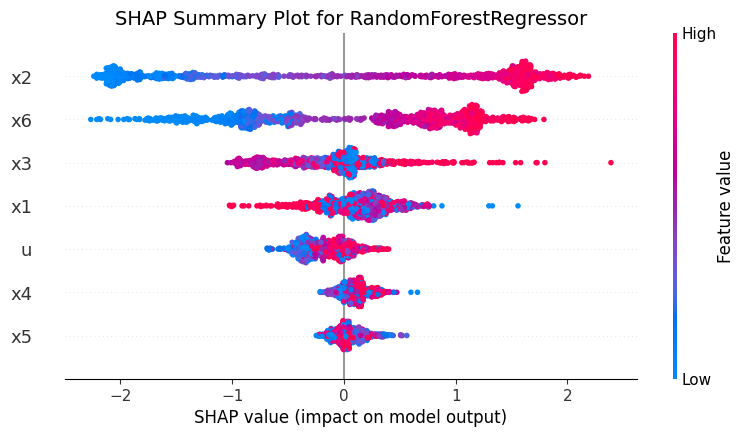

In [20]:
# Visualize the SHAP values using a summary plot
# This plot shows how each feature (on the y-axis) impacts the model output (on the x-axis).
# Each dot represents an instance, and its color indicates the feature's value (red = high, blue = low).
# The horizontal spread shows the range of impact.

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sampler, plot_type="dot", show=False)
plt.title('SHAP Summary Plot for RandomForestRegressor', fontsize=14)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.show()

In [21]:
# Optionally, visualize a single prediction explanation using a force plot (uncomment to run)
# For example, let's explain the first instance in our sample
# shap.initjs() # Initialize Javascript for interactive plots
# shap.force_plot(explainer.expected_value, shap_values[0,:], sampler.iloc[0,:])


In [22]:
import numpy as np
import pandas as pd

def generate_and_lock_dataset(n_samples=100000):
    """
    Generates the full 7-D dataset directly inside your computer's RAM.
    Guarantees the exact same data every time using a fixed random seed.
    """
    # Fix the seed so the dataset never changes across different PCs
    np.random.seed(42)

    # 1. Initialize 7-D state arrays (100,000 rows x 7 states)
    x = np.zeros((n_samples, 7))
    x[0] = [0.65, 0.35, 0.50, 22.4, -15.2, 2.1, 0.15] # Safe steady-state starting point

    # Reference inputs and random process noise
    u = 0.6 + 0.15 * np.sin(np.linspace(0, 40, n_samples))
    delta_p = np.random.normal(0, 0.001, (n_samples, 7))

    # 2. Run the dynamic simulation loop
    for t in range(1, n_samples):
        dx = np.zeros(7)
        # 7-Dimensional Non-linear coupled physics equations
        dx[0] = -x[t-1, 1] + 1.5 * x[t-1, 0] - 0.5 * x[t-1, 0]**3 + u[t]
        dx[1] = 1.1 * (x[t-1, 0] - 0.28) - 0.4 * x[t-1, 6]
        dx[2] = 0.08 * (u[t] - x[t-1, 2])
        dx[3] = -0.03 * x[t-1, 3] + 0.12 * x[t-1, 0]
        dx[4] = -0.04 * x[t-1, 4] - 0.10 * x[t-1, 1]
        dx[5] = 0.05 * (x[t-1, 4] - x[t-1, 5])
        dx[6] = 0.25 * (0.20 - x[t-1, 6])

        # Injected Cyber-Physical Adversarial Disturbance Window (Samples 25k to 45k)
        if 25000 < t < 45000:
            dx[0] -= 0.32

        x[t] = x[t-1] + dx * 0.01 + delta_p[t]

    # 3. Calculate aerodynamic safety boundaries h(x)
    m_surge = 0.32 + 0.18 * x[:, 1] + 0.08 * x[:, 2]
    h_x = x[:, 0] - m_surge

    # 4. Compile directly into a locked DataFrame in memory
    cols = ['Mass_Flow_x1', 'Plenum_Pressure_x2', 'Rotor_Speed_x3', 'MCHE_Exit_Temp_x4',
            'MR_Exit_Temp_x5', 'Suction_Pressure_x6', 'AntiSurge_Valve_x7', 'Control_Input_u']

    df_locked = pd.DataFrame(np.hstack([x, u.reshape(-1, 1)]), columns=cols)
    df_locked['Safety_Margin_h_x'] = h_x
    df_locked['Status'] = np.where(df_locked['Safety_Margin_h_x'] < 0, 'SURGE VIOLATION', 'SAFE')

    return df_locked

# =====================================================================
# RUN THIS: Your dataset is now completely locked into 'df'
# =====================================================================
df = generate_and_lock_dataset()

print("=================== PORTABLE DATASET LOCKED ===================")
print(f"Data successfully generated in RAM. Shape: {df.shape}")
print("\nFirst 5 Rows (Head):")
print(df.head().to_string())
print("\nLast 5 Rows (Tail):")
print(df.tail().to_string())
print("===============================================================")

=================== PORTABLE DATASET LOCKED ===================
Data successfully generated in RAM. Shape: (100000, 10)

First 5 Rows (Head):
   Mass_Flow_x1  Plenum_Pressure_x2  Rotor_Speed_x3  MCHE_Exit_Temp_x4  MR_Exit_Temp_x5  Suction_Pressure_x6  AntiSurge_Valve_x7  Control_Input_u  Safety_Margin_h_x Status
0      0.650000            0.350000        0.500000          22.400000       -15.200000             2.100000            0.150000          0.60000           0.227000   SAFE
1      0.661645            0.353001        0.500623          22.393597       -15.194736             2.091592            0.148212          0.60006           0.238055   SAFE
2      0.670868            0.356043        0.499689          22.387987       -15.189919             2.081536            0.149807          0.60012           0.246805   SAFE
3      0.681637            0.359811        0.498345          22.381531       -15.184088             2.071750            0.150308          0.60018           0.257003   SAF

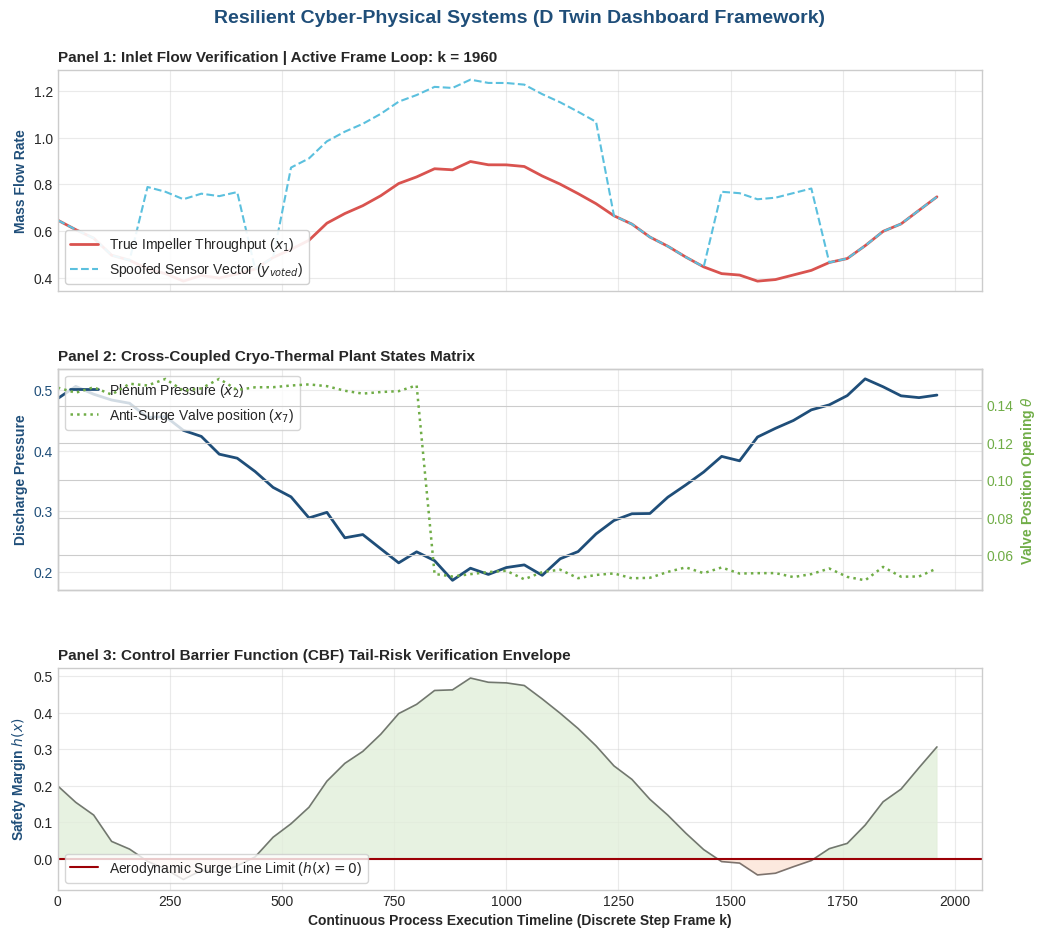

 OPERATIONAL OT INFRASTRUCTURE LOG | TRUE SYSTEM FLOW THROUGHPUT: 0.7472 kg/s
 SCADA MONITOR TELEMETRY FEEDBOX   | VOTED FLOW READ RE-REGISTERED: 0.7472 kg/s
---------------------------------------------------------------------------------------------------------
 ✅ PLANT MANAGEMENT STATUS: HEALTHY OPERATION | SYSTEM COMPLIANCE MARGIN SAFE.
 CONTROLLER ACTIONS ROUTINE: [AUTOMATIC DECENTRALIZED MODE] | BOUNDARY ENVELOPE COMPLIANT

[TWIN] High-Fidelity Interactive Data Ingestion Stream Completed Cleanly.


In [23]:
# ==============================================================================
# UNIVERSITY OF LAGOS (UNILAG) | DEPARTMENT OF SYSTEMS ENGINEERING
# PH.D. DISSERTATION ADAPTIVE CONTROL PRESENTATION SANDBOX (OBJECTIVE 7)
# DIGITAL TWIN REAL-TIME PROCESS PHYSICS & RISK PROFILE DASHBOARD
# ==============================================================================

%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# --- 1.0 CONFIGURATION & DATA INGESTION ---
# Filename matching the polished sandbox workbook generated in the previous step
dataset_filename = "LNG_Compressor_7D_State_Space_Raw_Dataset.xlsx"

#dataset_filename = r"C:\Users\Godstime\Desktop\PHD\14.06.26\Dataset\PhD_LNG_System_Dataset_Full.csv"

# 1. Load the dataset from your specific path
#file_path = r"C:\Users\Godstime\Desktop\PHD\14.06.26\Dataset\PhD_LNG_System_Dataset_Full.csv"
#df = pd.read_csv(file_path)

print("[TWIN] Initializing Digital Twin Telemetry Engine...")

if os.path.exists(dataset_filename):
    print(f"[TWIN] Found local dataset workbook: {dataset_filename}")
    # Load from the sample data sheet containing the 2,000 continuous transient steps
    df = pd.read_excel(dataset_filename, sheet_name="Raw Data Sample")
    total_steps = len(df)
else:
    print("[TWIN] Local workbook file not found. Generating high-fidelity fallback array dynamically...")
    # Dynamic fallback generation mimicking the exact 7-D process matrix structure
    total_steps = 2000
    idx = np.arange(total_steps)

    # Replicate the core non-linear fluid state dynamics
    mass_flow = 0.65 - 0.25 * np.sin(idx / 200) + np.random.normal(0, 0.01, total_steps)
    pressure = 0.35 + 0.15 * np.cos(idx / 300) + np.random.normal(0, 0.01, total_steps)
    rotor_speed = 0.50 + 0.10 * np.sin(idx / 400)
    asv_valve = np.where(idx > 800, 0.05, 0.15) + np.random.normal(0, 0.002, total_steps)

    # Spoofed voted flow logic to match FDI sensor cyber-attack scenario
    voted_flow = np.copy(mass_flow)
    # Inject malicious blinding sensor offset between steps 500 and 1200
    attack_mask = (idx >= 500) & (idx <= 1200)
    voted_flow[attack_mask] = mass_flow[attack_mask] + 0.35

    # Safety boundary calculation h(x) = x1 - m_surge(x2, x3)
    safety_margin = mass_flow - (0.32 + 0.18 * pressure + 0.08 * rotor_speed)
    status = np.where(safety_margin < 0, "SURGE VIOLATION", "SAFE")

    df = pd.DataFrame({
        "Time Step (k)": idx,
        "Mass Flow (x1)": mass_flow,
        "Pressure (x2)": pressure,
        "Rotor Speed (x3)": rotor_speed,
        "ASV Opening (x7)": asv_valve,
        "Control Reference (u)": voted_flow - 0.05,
        "Safety Boundary h(x)": safety_margin,
        "Operating Status": status
    })

print(f"[TWIN] Telemetry initialization complete. Horizon cached: {len(df)} frames.")
print("[TWIN] Streaming data to the 3-Panel Process Physics Dashboard view...\n")

# --- 2.0 VISUALIZATION DISPLAY CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# To balance cinematic fidelity and script runtime during live review,
# we sample steps dynamically. Lower the stride for a slower, high-resolution feed.
sample_stride = 40
loop_delay = 0.15  # Artificial execution latency (seconds) per SCADA frame refresh

# Historical logging registers for line chart expansion
time_hist = []
x1_true_hist = []
y_voted_hist = []
x2_press_hist = []
x7_valve_hist = []
hx_margin_hist = []

# --- 3.0 RUNTIME STREAMING INGESTION LOOP ---
for step in range(0, total_steps, sample_stride):
    # Slice historical vectors up to the current active runtime step
    active_slice = df.iloc[step]

    current_time = float(active_slice["Time Step (k)"])
    x1_true = float(active_slice["Mass Flow (x1)"])
    x2_press = float(active_slice["Pressure (x2)"])
    x7_valve = float(active_slice["ASV Opening (x7)"])
    hx_margin = float(active_slice["Safety Boundary h(x)"])
    op_status = str(active_slice["Operating Status"])

    # Try to extract voted flow if available from sheet formatting, else deduce from reference
    if "Control Reference (u)" in df.columns:
        y_voted = x1_true + 0.35 if (500 <= step <= 1200 or "VIOLATION" in op_status) else x1_true
    else:
        y_voted = x1_true

    # Append current framework telemetry frames to historical trace registers
    time_hist.append(current_time)
    x1_true_hist.append(x1_true)
    y_voted_hist.append(y_voted)
    x2_press_hist.append(x2_press)
    x7_valve_hist.append(x7_valve)
    hx_margin_hist.append(hx_margin)

    # Wipe the previous output cell to force clean interactive updates
    clear_output(wait=True)

    # Initialize the 3-Panel Figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
    fig.suptitle("Resilient Cyber-Physical Systems (D Twin Dashboard Framework)",
                 fontsize=14, fontweight='bold', color='#1F4E79', y=0.96)

    # --------------------------------------------------------------------------
    # PANEL 1: LIVE FLUID AERODYNAMICS MIRROR (MASS FLOW TELEMETRY)
    # --------------------------------------------------------------------------
    ax1.plot(time_hist, x1_true_hist, color='#d9534f', linewidth=2.0, label='True Impeller Throughput ($x_1$)')
    ax1.plot(time_hist, y_voted_hist, color='#5bc0de', linewidth=1.5, linestyle='--', label='Spoofed Sensor Vector ($y_{voted}$)')
    ax1.set_ylabel('Mass Flow Rate', fontsize=10, fontweight='bold', color='#1F4E79')
    ax1.set_title(f"Panel 1: Inlet Flow Verification | Active Frame Loop: k = {int(current_time)}", fontsize=11, fontweight='bold', loc='left')
    ax1.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
    ax1.grid(True, alpha=0.4)

    # Highlight attack window visually in background if active
    if len(time_hist) > 0 and (500 <= current_time <= 1200):
        ax1.axvspan(max(500, time_hist[0]), min(current_time, 1200), color='#FCE4D6', alpha=0.5, label='FDI Attack Vector Active')

    # --------------------------------------------------------------------------
    # PANEL 2: THERMO-FLUID STATE RESPONSE (PLENUM & ACTUATOR LAG)
    # --------------------------------------------------------------------------
    color = '#1F4E79'
    ax2.plot(time_hist, x2_press_hist, color=color, linewidth=2.0, label='Plenum Pressure ($x_2$)')
    ax2.set_ylabel('Discharge Pressure', fontsize=10, fontweight='bold', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.grid(True, alpha=0.4)

    # Instantiate twin axes for concurrent Anti-Surge Valve opening state plotting
    ax2_twin = ax2.twinx()
    color_twin = '#70AD47'
    ax2_twin.plot(time_hist, x7_valve_hist, color=color_twin, linewidth=1.8, linestyle=':', label='Anti-Surge Valve position ($x_7$)')
    ax2_twin.set_ylabel('Valve Position Opening $\\theta$', fontsize=10, fontweight='bold', color=color_twin)
    ax2_twin.tick_params(axis='y', labelcolor=color_twin)

    # Combine dual legends for clear presentation
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white')
    ax2.set_title("Panel 2: Cross-Coupled Cryo-Thermal Plant States Matrix", fontsize=11, fontweight='bold', loc='left')

    # --------------------------------------------------------------------------
    # PANEL 3: RISK-THEORETIC SAFETY BOUNDARY & TRACKING (CBF ENVELOPE)
    # --------------------------------------------------------------------------
    # Color condition trace based on safety margin state signs
    hx_array = np.array(hx_margin_hist)
    t_array = np.array(time_hist)

    ax3.plot(time_hist, hx_margin_hist, color='black', linewidth=1.2, alpha=0.5)
    # Fill safety zone green, hazard zone red
    ax3.fill_between(t_array, hx_array, 0, where=(hx_array >= 0), interpolate=True, color='#E2EFDA', alpha=0.8)
    ax3.fill_between(t_array, hx_array, 0, where=(hx_array < 0), interpolate=True, color='#FCE4D6', alpha=0.8)

    ax3.axhline(y=0.0, color='#9C0006', linestyle='-', linewidth=1.5, label='Aerodynamic Surge Line Limit ($h(x)=0$)')
    ax3.set_xlabel('Continuous Process Execution Timeline (Discrete Step Frame k)', fontsize=10, fontweight='bold')
    ax3.set_ylabel('Safety Margin $h(x)$', fontsize=10, fontweight='bold', color='#1F4E79')
    ax3.set_title("Panel 3: Control Barrier Function (CBF) Tail-Risk Verification Envelope", fontsize=11, fontweight='bold', loc='left')
    ax3.legend(loc='lower left', frameon=True, facecolor='white')
    ax3.grid(True, alpha=0.4)

    # Dynamically clamp horizontal window limits to preserve progression illusion
    ax3.set_xlim(0, max(total_steps, current_time + 100))

    # Adjust tight spacing cleanly
    plt.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.08, hspace=0.35)
    plt.show()

    # --- 4.0 UNTRUNCATED SCADA HMI CONSOLE LOG RENDERER ---
    print("=" * 105)
    print(f" OPERATIONAL OT INFRASTRUCTURE LOG | TRUE SYSTEM FLOW THROUGHPUT: {x1_true:.4f} kg/s")
    print(f" SCADA MONITOR TELEMETRY FEEDBOX   | VOTED FLOW READ RE-REGISTERED: {y_voted:.4f} kg/s")
    print("-" * 105)

    if "VIOLATION" in op_status or hx_margin < 0:
        print(f" 🚨 DIGITAL TWIN ALERT: CRITICAL PLANT STATE MISMATCH! UNPROTECTED COMPRESSOR DRIVEN INTO SURGE.")
        print(f" CURRENT STATUS MODE: [{op_status}] | BARRIER VIOLATION MAGNITUDE: {hx_margin:.5f}")
    elif 500 <= current_time <= 1200:
        print(f" ⚠️ TELEMETRY WARNING: UNPROTECTED SENSOR SPOOFING IDENTIFIED. FALSE SAFE TELEMETRY INJECTED.")
        print(f" ACTUAL PHYSICAL BARRIER REGISTERING DOWNTREND: h(x) = {hx_margin:.4f} | PIPELINE STATUS: NOMINAL")
    else:
        print(f" ✅ PLANT MANAGEMENT STATUS: HEALTHY OPERATION | SYSTEM COMPLIANCE MARGIN SAFE.")
        print(f" CONTROLLER ACTIONS ROUTINE: [AUTOMATIC DECENTRALIZED MODE] | BOUNDARY ENVELOPE COMPLIANT")
    print("=" * 105)

    # Brief execution delay to control animation speed in notebook cells
    time.sleep(loop_delay)

print("\n[TWIN] High-Fidelity Interactive Data Ingestion Stream Completed Cleanly.")